In [63]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
# import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Coleta dos dados

In [64]:
results_flows_directories = glob.glob('../../results/results_flows*/*')
results_flows_directories

['../../results\\results_flows\\darsppo_s_50_p_6_a_1.0_c_0',
 '../../results\\results_flows\\ga_s_50_p_6_a_1.0_c_0',
 '../../results\\results_flows\\hephaestus_s_50_p_6_a_1.0_c_0',
 '../../results\\results_flows\\kuririnPPO_s_50_p_6_a_1.0_c_0']

In [65]:
metricas_de_coleta = ['tempo',
                        'cpu_utilization',
                        'cache_utilization',
                        'bandwidth_utilization',
                        'success',
                        'latency',
                        'decision_time_ms',
                        'running_sfcs',
                        'cpu_saved',
                        'shared_vnfs',
                        'cpu_per_flow',
                        'cache_per_flow',
                        "total_energy_consumption",
                        "desvio_padrao_latencia_por_sessão",
                        "acceptance_rate",
                        "energy_consumption_per_flow"]

### Função auxiliar que insere a coluna de desvio padrão da latencia nas SFCs de mesma sessão

In [66]:
import pandas as pd
import numpy as np

def calcular_desvio_padrao_por_sessao(df):
    """
    Calcula o desvio padrão da latência por sessão e o adiciona ao DataFrame.

    A sessão é extraída da coluna 'sfc_id' (ex: 'sfc_unique_p5_1' -> sessão '1').
    O desvio padrão de um grupo com apenas um membro é 'NaN', que é
    convertido para 0.

    Argumentos:
    df (pd.DataFrame): O DataFrame de entrada. Deve conter as colunas
                         'sfc_id' e 'latency'.

    Retorna:
    pd.DataFrame: Uma cópia do DataFrame original com a nova coluna
                  'desvio_padrao_latencia_por_sessão'.
    """
    # Criar uma cópia para evitar modificar o DataFrame original (boa prática)
    df_modificado = df.copy()

    # 1. Extrair o ID da sessão da coluna 'sfc_id'
    #    Ex: 'sfc_unique_p5_1' -> '1'
    df_modificado['session_id'] = df_modificado['sfc_id'].str.split('_').str[-1]

    # 2. Calcular o desvio padrão da 'latency' para cada 'session_id'
    #    A função transform() aplica o resultado do cálculo de volta a 
    #    todas as linhas originais do grupo.
    df_modificado['desvio_padrao_latencia_por_sessão'] = df_modificado.groupby('session_id')['latency'].transform('std')

    # 3. Tratar casos de sessão única
    #    Se uma sessão tiver apenas uma entrada, seu desvio padrão será 'NaN'
    #    (Não é possível calcular desvio com um único ponto).
    #    Substituímos esses 'NaN' por 0, pois não há desvio.
    df_modificado['desvio_padrao_latencia_por_sessão'] = df_modificado['desvio_padrao_latencia_por_sessão'].fillna(0)

    # 4. (Opcional) Remover a coluna temporária 'session_id'
    df_modificado = df_modificado.drop(columns=['session_id'])

    return df_modificado



def calcular_consumo_energia_por_fluxo(df):
    """
    Calcula o consumo de energia por fluxo e o adiciona ao DataFrame.

    A nova coluna se chamará 'energy_consumption_per_flow'.
    O cálculo é 'total_energy_consumption' / 'running_sfcs'.

    Casos onde 'running_sfcs' é 0 (o que causaria uma divisão por zero)
    terão o resultado 'energy_consumption_per_flow' definido como 0.0.

    Argumentos:
    df (pd.DataFrame): O DataFrame de entrada. Deve conter as colunas
                         'total_energy_consumption' e 'running_sfcs'.

    Retorna:
    pd.DataFrame: Uma cópia do DataFrame original com a nova coluna
                  'energy_consumption_per_flow'.
    """
    # 1. Criar uma cópia para evitar modificar o DataFrame original
    df_modificado = df.copy()

    # 2. Definir o nome da nova coluna (em inglês, como solicitado)
    nova_coluna = 'energy_consumption_per_flow'
    
    # 3. Calcular a divisão, tratando a divisão por zero
    #    Usamos np.where() como uma forma segura de fazer um 'if/else'
    #    em colunas do Pandas.
    #
    #    Condição: A coluna 'running_sfcs' é igual a 0?
    #    Se sim (True): O valor da nova coluna será 0.0
    #    Se não (False): O valor será a divisão normal
    df_modificado[nova_coluna] = np.where(
        df_modificado['running_sfcs'] == 0,  # Condição
        0.0,                                 # Valor se True
        df_modificado['total_energy_consumption'] / df_modificado['running_sfcs'] # Valor se False
    )

    return df_modificado

In [67]:
big_data = pd.DataFrame()

def colect_data_from_alg_directory(results_flows_directories):
    data_nla = []

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('\\')[-1].split('_')
        share = 'y'
        alg_name = simu_exec_name[0].split("\\")[0]
        print(alg_name)
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'vegeta':
            alg_name = 'Resilient-OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'
        if alg_name == 'greedyb':
            alg_name = 'GreedyB'
        if alg_name == 'kuririnPPO':
            alg_name = 'Kuririn PPO'
        if alg_name == "darsppo":
            alg_name = "DARSPPO"
        if alg_name == "hephaestus":
            alg_name = "hephaestus"

        files = os.listdir(alg_dir)
        print(f"Simulação:{alg_name}") 
        print("Quantidade de csv: ",len(files))
        
        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                simulation_df = calcular_desvio_padrao_por_sessao(simulation_df)
                simulation_df = calcular_consumo_energia_por_fluxo(simulation_df)
            except:
                continue
        
            primeiro_tempo = simulation_df['timestamp'].values[0]
            simulation_df['tempo'] = simulation_df[['timestamp']].applymap(lambda x: x - primeiro_tempo)
            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            
            if simulation_is_success: 
                simulacoes_okays = simulacoes_okays + 1
                simulation_df = simulation_df[metricas_de_coleta]
                
                #Arrendondar tempo
                simulation_df['tempo'] = simulation_df['tempo'].astype(int)
                
                simulation_df = simulation_df.replace('None', pd.NA)

                latency_col = simulation_df[['tempo','latency']] 
                latency_col.dropna(inplace=True)
                latency_col.loc[:, 'latency'] = latency_col['latency'].astype(float)


                ###############################################
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                simulation_df['success'] = cumulative_avg_success
                ###############################################

                simulation_df = simulation_df.groupby('tempo', as_index=False).mean(numeric_only=True)
                latency_df = latency_col.groupby('tempo',as_index=False).mean(numeric_only=True).reset_index()
                
                tempo_range = simulation_df['tempo'].max()
                df_mean = simulation_df.set_index('tempo').reindex(range(tempo_range + 1))
                df_mean = df_mean.fillna(method='ffill')
                df_mean = df_mean.reset_index()


                latency_df = latency_df.set_index('tempo').reindex(range(tempo_range + 1))
                latency_df = latency_df.fillna(method='ffill')
                latency_df = latency_df.reset_index()
         
                df_mean['latency'] = latency_df['latency']
                df_mean['algorithm'] = alg_name
                #df_mean['sharing'] = share
                df_mean= df_mean.iloc[0:1000]
                data_nla.append(df_mean)

        data_nla_f = pd.concat(data_nla)
        print("Simulações de sucesso: ",simulacoes_okays)
        print("Dados Nulos: ", data_nla_f.isnull().sum().sum())
        print()

    return data_nla_f

In [68]:
big_data = colect_data_from_alg_directory(results_flows_directories)

darsppo
Simulação:DARSPPO
Quantidade de csv:  33
Simulações de sucesso:  23
Dados Nulos:  0

ga
Simulação:GA
Quantidade de csv:  33
Simulações de sucesso:  33
Dados Nulos:  0

hephaestus
Simulação:hephaestus
Quantidade de csv:  50
Simulações de sucesso:  47
Dados Nulos:  0

kuririnPPO
Simulação:Kuririn PPO
Quantidade de csv:  33
Simulações de sucesso:  33
Dados Nulos:  0



In [69]:
big_data['acceptance_rate'] = big_data['acceptance_rate'] / 100

In [70]:
big_data

,tempo,cpu_utilization,cache_utilization,bandwidth_utilization,success,latency,decision_time_ms,running_sfcs,cpu_saved,shared_vnfs,cpu_per_flow,cache_per_flow,total_energy_consumption,desvio_padrao_latencia_por_sessão,acceptance_rate,energy_consumption_per_flow,algorithm
0,0,0.008883,0.041567,0.028483,1.000000,6.229167,19.7760,7.0,0.000000,8.500000,1.012403,9.350000,2196.907857,1.647055,1.000000,440.322342,DARSPPO
1,1,0.008883,0.041567,0.028483,1.000000,6.229167,19.7760,7.0,0.000000,8.500000,1.012403,9.350000,2196.907857,1.647055,1.000000,440.322342,DARSPPO
2,2,0.008883,0.041567,0.028483,1.000000,6.229167,19.7760,7.0,0.000000,8.500000,1.012403,9.350000,2196.907857,1.647055,1.000000,440.322342,DARSPPO
3,3,0.008883,0.041567,0.028483,1.000000,6.229167,19.7760,7.0,0.000000,8.500000,1.012403,9.350000,2196.907857,1.647055,1.000000,440.322342,DARSPPO
4,4,0.008883,0.041567,0.028483,1.000000,6.229167,19.7760,7.0,0.000000,8.500000,1.012403,9.350000,2196.907857,1.647055,1.000000,440.322342,DARSPPO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,0.451000,0.465667,0.276133,0.937469,11.916667,5.9615,62.0,53.993333,58.333333,12.586235,9.936593,3055.586871,2.201372,0.937469,49.312285,Kuririn PPO
996,996,0.451000,0.465667,0.276133,0.937469,11.916667,5.9615,62.0,53.993333,58.333333,12.586235,9.936593,3055.586871,2.201372,0.937469,49.312285,Kuririn PPO
997,997,0.455300,0.474000,0.267100,0.937713,13.250000,5.8765,60.0,48.660000,56.000000,12.766500,10.450000,3002.393605,2.076094,0.937713,50.039893,Kuririn PPO
998,998,0.455300,0.474000,0.267100,0.937713,13.250000,5.8765,60.0,48.660000,56.000000,12.766500,10.450000,3002.393605,2.076094,0.937713,50.039893,Kuririn PPO


In [71]:
# --- NOVO CÓDIGO ADICIONADO ---
# Filtra o DataFrame para incluir apenas dados a partir dos 200 segundos
print(f"Linhas originais em big_data: {len(big_data)}")
big_data = big_data[big_data['tempo'] >= 200].copy()
print(f"Linhas após filtrar tempo >= 200s: {len(big_data)}")
# ---------------------------------

# O resto da sua célula 8 continua normalmente
big_data["CPU Salva por SFC"] =  big_data["cpu_saved"] / big_data["running_sfcs"] 
big_data["CPU Salva por Servidor"] =  big_data["cpu_saved"] / 35

Linhas originais em big_data: 133202
Linhas após filtrar tempo >= 200s: 106002


In [72]:
big_data["CPU Salva por SFC"] =  big_data["cpu_saved"] / big_data["running_sfcs"] 
big_data["CPU Salva por Servidor"] =  big_data["cpu_saved"] / 35 

In [73]:
# Suposições
capacidade_maxima_banda_gbps = 10  # Capacidade máxima da banda em Gbps

# Calculando métricas
big_data["eficiencia de cpu"] =  big_data["cpu_utilization"] / big_data["running_sfcs"] 

big_data["eficiencia de banda"] =   big_data["bandwidth_utilization"]   / big_data["running_sfcs"] 
big_data["eficiencia de cache"] =  big_data["cache_utilization"]  / big_data["running_sfcs"] 

# big_data["bit_rate"] = big_data["practical_bandwidth_utilization"] * capacidade_maxima_banda_gbps

# Função para calcular a pontuação da latência
def calcular_pontuacao_latencia(latencia):
    if pd.isna(latencia):
        return 0  # Latência Nula
    elif latencia > 6:
        return -1  # Latência Ruim
    else:
        return 2  # Latência Boa

# Função para calcular a pontuação da aceitação
def calcular_pontuacao_success(success):
    # Convertendo a taxa de sucesso para uma escala de 0 a 1 e multiplicando por 10 para obter uma pontuação máxima de 10
    return success * 10

# Aplicando as funções para calcular as pontuações
big_data['pontuacao_latencia'] = big_data['latency'].apply(calcular_pontuacao_latencia)
big_data['pontuacao_success'] = big_data['success'].apply(calcular_pontuacao_success)

# Calculando a métrica final de qualidade do serviço
big_data['QoS'] = big_data['pontuacao_latencia'] + big_data['pontuacao_success']

In [74]:
# Lista de algoritmos a serem analisados
# algoritmos = ['GreedyB', 'Kuririn PPO']
algoritmos = ['hephaestus', "DARSPPO", 'Kuririn PPO', "GA"]

# Dicionário para armazenar os dados processados de cada algoritmo
dados_processados = {}

def process_data(data):
    data = data.groupby('tempo').mean()
    return data

for alg in algoritmos:
    # Filtrando os dados baseado no algoritmo e na condição de compartilhamento
    dados_filtrados = big_data[(big_data['algorithm'] == alg)]

    # Removendo as colunas 'algor}ithm' e 'sharing'
    dados_filtrados = dados_filtrados.drop(['algorithm'], axis=1)

    # Processando os dados filtrados
    dados_processados[alg] = process_data(dados_filtrados)


In [75]:
dados_processados

{'hephaestus':        cpu_utilization  cache_utilization  bandwidth_utilization   success  \
 tempo                                                                        
 200           0.395785           0.386730               0.417112  0.860806   
 201           0.397087           0.387528               0.418976  0.861175   
 202           0.396599           0.387083               0.416502  0.861400   
 203           0.397884           0.391238               0.418508  0.860634   
 204           0.396025           0.389912               0.414129  0.861016   
 ...                ...                ...                    ...       ...   
 995           0.406577           0.432744               0.445246  0.835294   
 996           0.407356           0.428999               0.444237  0.835348   
 997           0.408109           0.429892               0.443848  0.835384   
 998           0.408048           0.432560               0.440776  0.835263   
 999           0.410844           0.43

In [76]:
# Agora, dados_processados contém os dados processados para cada algoritmo
# Acessando os dados processados para cada algoritmo:
# greedyb_data_share = dados_processados['GreedyB']
kuririnPPO_data_share = dados_processados['Kuririn PPO']
DARSPPO_data_share = dados_processados['DARSPPO']

# res_oscim_data_share = dados_processados['Resilient-OSCIM']

In [117]:
import re
import os
from typing import Dict, Sequence, Optional, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def create_boxplot(
    data_series_dict: Dict[str, Sequence],
    yaxis_title: str = 'Y Axis',
    xaxis_title: str = 'Time (s)',  # This will be removed later
    steps: Optional[int] = 200,
    fill_missing: bool = True,
    bfill_leading: bool = True,
    show: bool = True,
    pdf_filename: Optional[str] = None,
    width: int = 950,
    height: int = 600,
    show_outliers: bool = True,
) -> Tuple[Optional[plt.Figure], pd.DataFrame]:
    """
    Draws boxplots by windows for an arbitrary number of data series (Matplotlib).
    - Groups by time windows (defined by 'steps')
    - Creates boxplots per algorithm in each window, with lateral offset (grouped)
    - Applies hatch and colors per algorithm; small outliers with the same color
    """

    # ---- helpers ------------------------------------------------------------
    def _as_series(y: Sequence) -> pd.Series:
        if y is None:
            return pd.Series(dtype="float64")
        s = pd.Series(y, dtype="float64")
        return pd.to_numeric(s, errors="coerce")

    def _window_labels(n: int, step: Optional[int]) -> np.ndarray:
        """Create labels for time windows."""
        if n == 0 or step is None or step <= 0:
            return np.arange(n, dtype=int)
        groups = np.repeat(np.arange((n + step - 1) // step), step)[:n]
        return (groups + 1) * step

    # ---- build long dataframe ----------------------------------------------
    frames: List[pd.DataFrame] = []
    warnings: List[str] = []

    for label, data in data_series_dict.items():
        s = _as_series(data)
        if s.empty:
            continue

        if fill_missing:
            s = s.ffill()
            if bfill_leading and s.isna().any():
                s = s.bfill()

        s = s.dropna()
        if s.empty:
            warnings.append(f"[AVISO] Série '{label}' ignorada (todos os valores são NaN).")
            continue

        time_labels = _window_labels(len(s), steps)
        frames.append(pd.DataFrame({
            xaxis_title: time_labels,
            yaxis_title: s.values,
            "Algorithm": label
        }))

    if not frames:
        print("[ERRO] Nenhuma série válida para plotar (vazia ou somente NaN).")
        return None, pd.DataFrame()

    df_plot = pd.concat(frames, ignore_index=True)
    for msg in warnings:
        print(msg)

    # ---- plotting (Matplotlib) ---------------------------------------------
    plt.rcParams['hatch.linewidth'] = 0.5
    plt.rcParams.update({
        'font.size': 17,
        'axes.labelsize': 15,
        'legend.fontsize': 14,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'axes.titlesize': 15,
    })

    # Unique x categories in correct order
    x_vals = sorted(df_plot[xaxis_title].unique())
    alg_order = list(df_plot['Algorithm'].unique())
    n_alg = 4  # Set this to 4 for 4 groups per time window (adjustment)

    # Colors: use global 'cores_algoritmos' if present; fallback to tab10
    def _color_for(i: int, name: str) -> any:
        try:
            return cores_algoritmos.get(name, plt.cm.tab10(i % 10))  # type: ignore
        except Exception:
            return plt.cm.tab10(i % 10)

    hatch_patterns = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

    # Figure size: convert px -> inches (approx 96 dpi baseline)
    dpi_guess = 96
    fig_w = max(6, width / dpi_guess)
    fig_h = max(4, height / dpi_guess)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # group width allocation
    group_full_width = 0.8
    box_width = group_full_width / n_alg
    positions_base = np.arange(len(x_vals))

    legend_handles: List[Patch] = []

    # For each algorithm, draw a series of boxplots offset within each group
    for i, alg in enumerate(alg_order):
        color = _color_for(i, alg)
        hatch = hatch_patterns[i % len(hatch_patterns)]

        # Gather data per window (keeping order of x_vals)
        df_alg = df_plot[df_plot['Algorithm'] == alg]
        data_per_window = [
            df_alg[df_alg[xaxis_title] == x][yaxis_title].dropna().values
            for x in x_vals
        ]

        # Offsets to place boxes side-by-side inside each window group
        offset = (i - n_alg / 2) * box_width + box_width / 2
        positions = positions_base + offset

        flier_style = dict(
            marker='o',
            markersize=3,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7
        )

        bp = ax.boxplot(
            data_per_window,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=show_outliers,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5,
                          linewidth=1.2, edgecolor='black'),
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color=color, linewidth=1.2),
            capprops=dict(color=color, linewidth=1.2),
            flierprops=flier_style if show_outliers else dict(marker='o', markersize=0.1)
        )

        # Extra set ensures styling is consistent
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.2)
            patch.set_alpha(0.5)
            patch.set_hatch(hatch)

        legend_handles.append(Patch(
            facecolor=color, edgecolor='black', hatch=hatch, alpha=0.5, label=alg
        ))

    # Axes labels, ticks, grid
    ax.set_ylabel(yaxis_title, labelpad=10)
    ax.set_xlabel("")  # Removed x-axis title
    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(x) for x in x_vals], rotation=25)
    
    # Remove the x-axis scale (ticks and numbers)
    ax.set_xticklabels([])  # No labels
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    # Legend above the plot (adjusted for position)
    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.1),
        ncol=min(4, n_alg),
        frameon=False,
        handlelength=2.2,
        borderpad=0.3,
        labelspacing=0.4
    )

    plt.tight_layout(pad=0.9)

    # Export
    if pdf_filename:
        try:
            fig.savefig(pdf_filename, dpi=300, bbox_inches='tight')
            print(f"Gráfico exportado como PDF: {pdf_filename}")
        except Exception as e:
            # Fallback simples para PNG se houver problema no PDF
            base, _ = os.path.splitext(pdf_filename)
            png_out = f"{base}.png"
            print(f"Falha ao exportar PDF ({e.__class__.__name__}). Salvando PNG.")
            fig.savefig(png_out, dpi=300, bbox_inches='tight')
            print(f"Gráfico exportado como PNG: {png_out}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, df_plot


Gráfico exportado como PDF: boxplot_cpu_utilization_with_Outliers.pdf


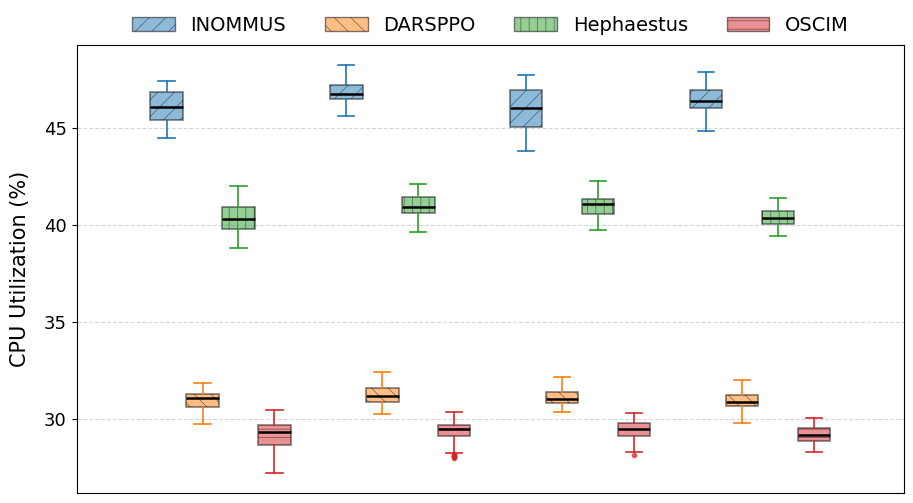

Gráfico exportado como PDF: boxplot_cpu_utilization_Clean.pdf


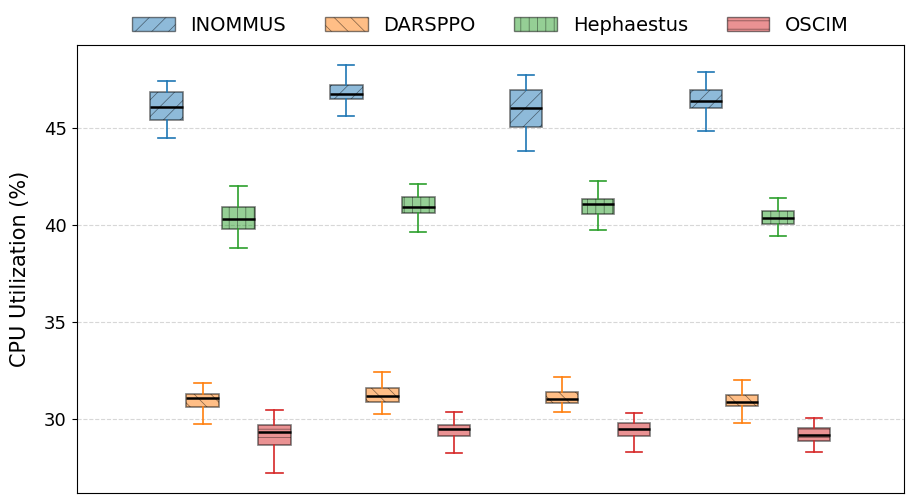

Gráfico exportado como PDF: boxplot_cache_utilization_with_Outliers.pdf


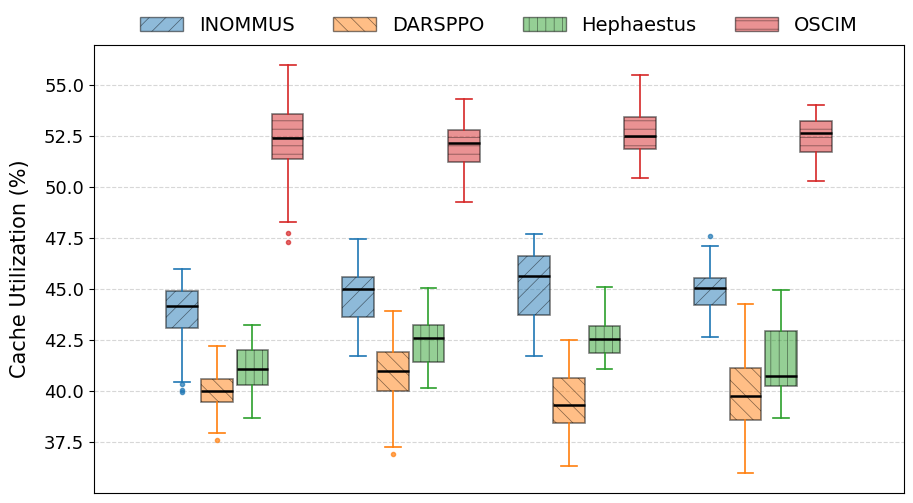

Gráfico exportado como PDF: boxplot_cache_utilization_Clean.pdf


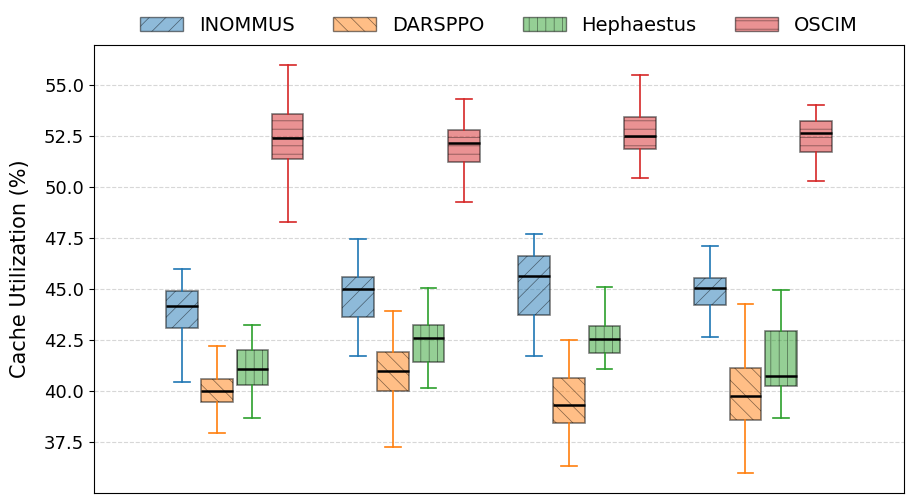

Gráfico exportado como PDF: boxplot_bandwidth_utilization_with_Outliers.pdf


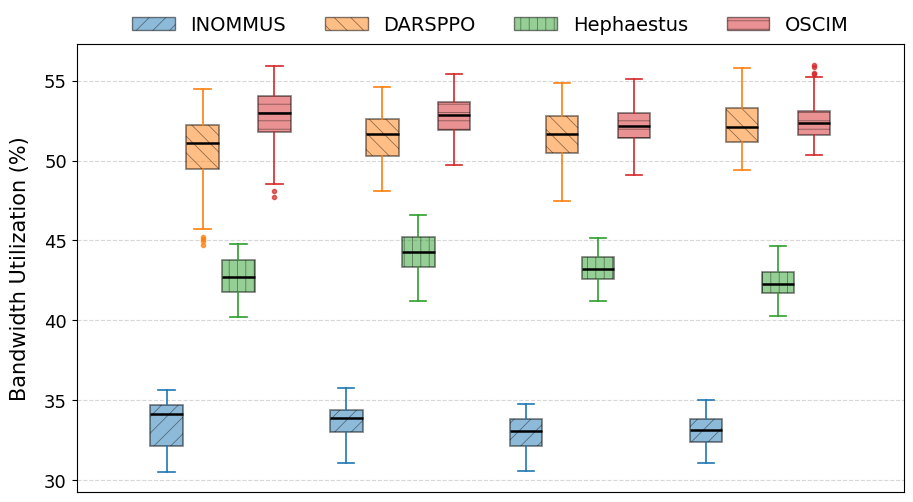

Gráfico exportado como PDF: boxplot_bandwidth_utilization_Clean.pdf


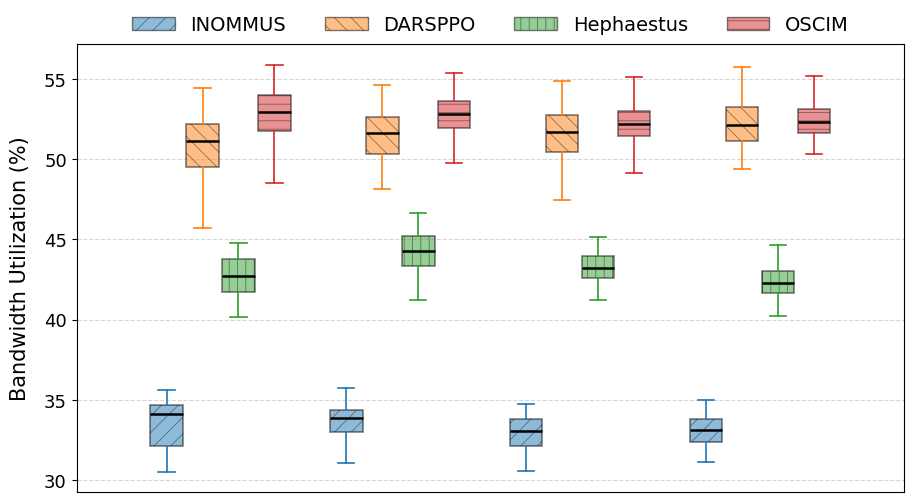

Gráfico exportado como PDF: boxplot_latency_with_Outliers.pdf


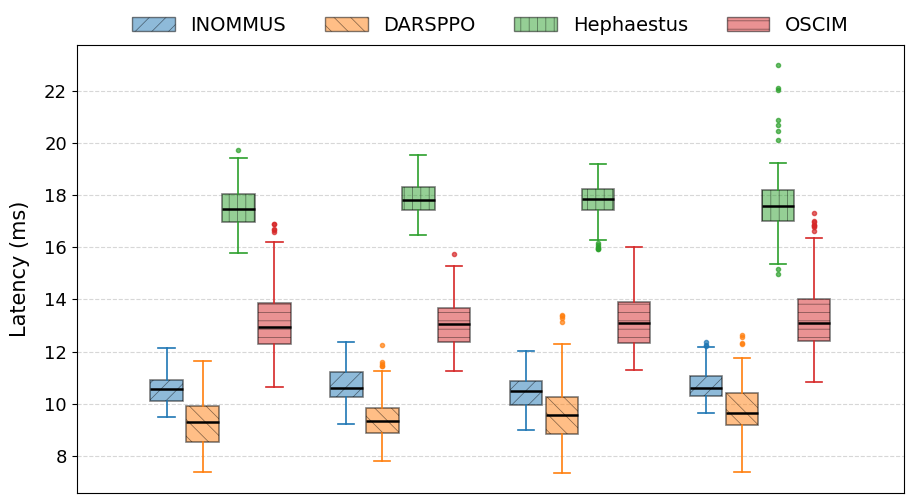

Gráfico exportado como PDF: boxplot_latency_Clean.pdf


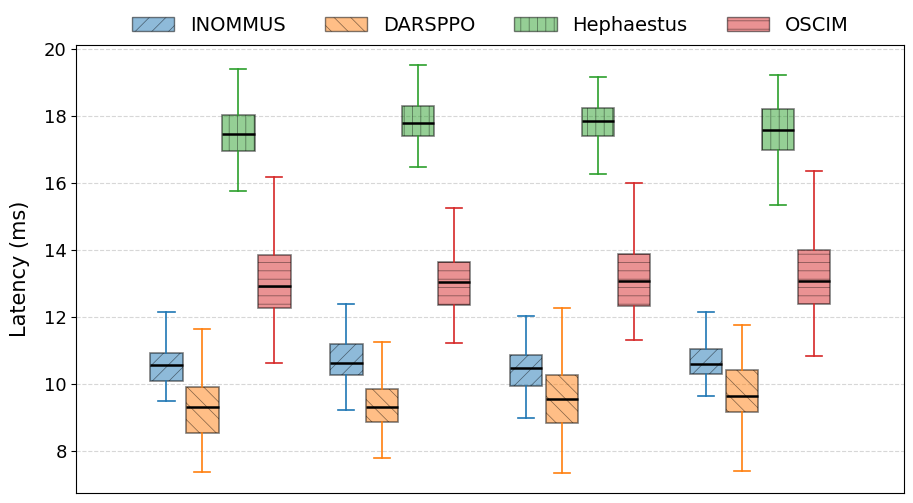

Gráfico exportado como PDF: boxplot_acceptance_rate_with_Outliers.pdf


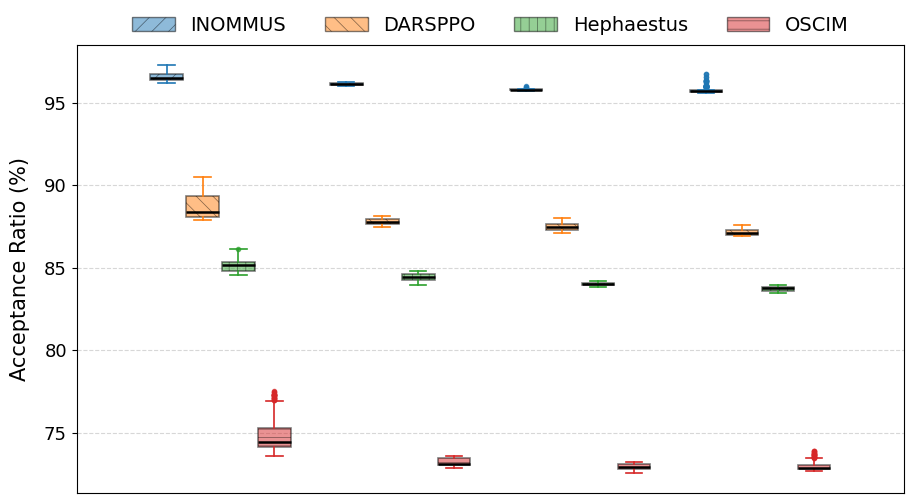

Gráfico exportado como PDF: boxplot_acceptance_rate_Clean.pdf


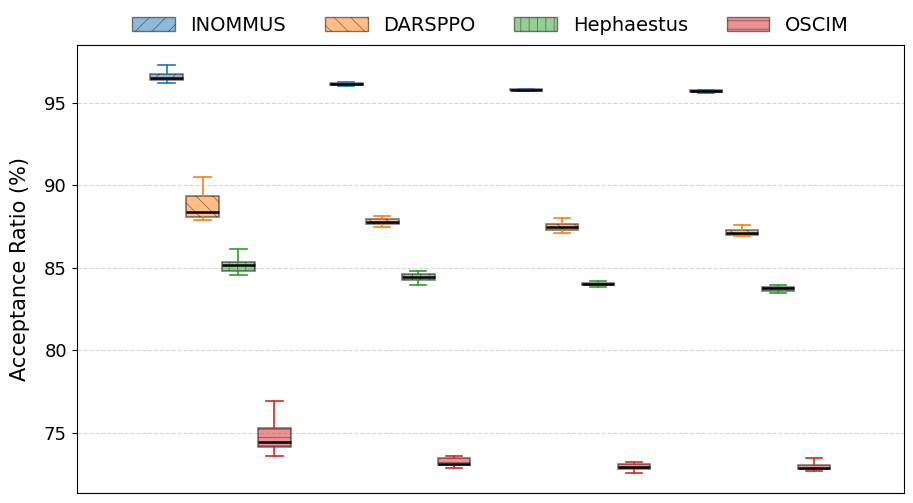

Gráfico exportado como PDF: boxplot_decision_time_ms_with_Outliers.pdf


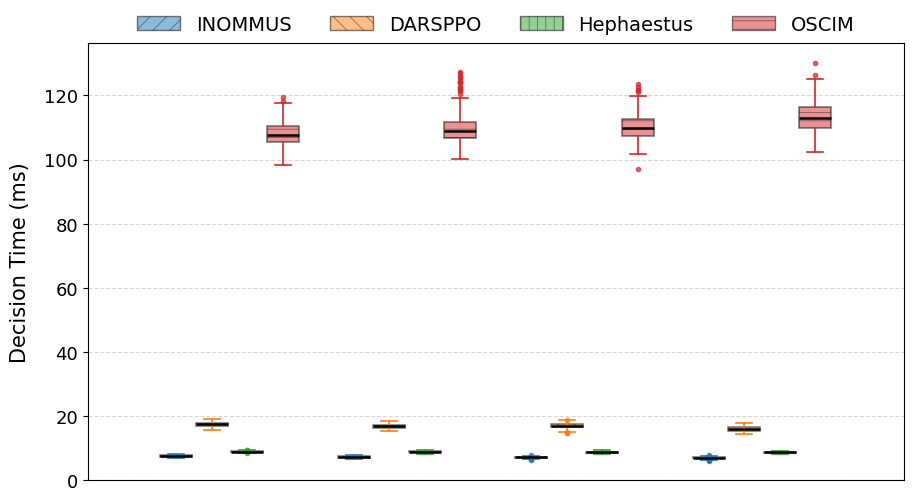

Gráfico exportado como PDF: boxplot_decision_time_ms_Clean.pdf


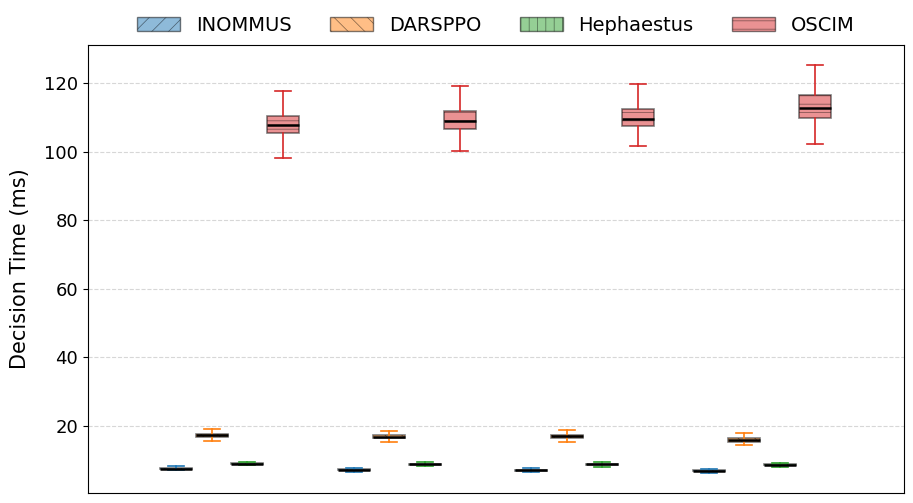

Gráfico exportado como PDF: boxplot_shared_vnfs_with_Outliers.pdf


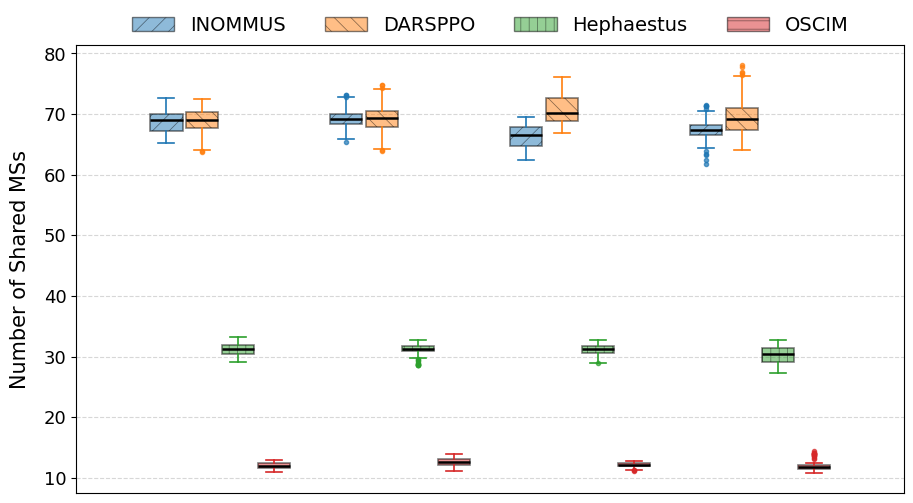

Gráfico exportado como PDF: boxplot_shared_vnfs_Clean.pdf


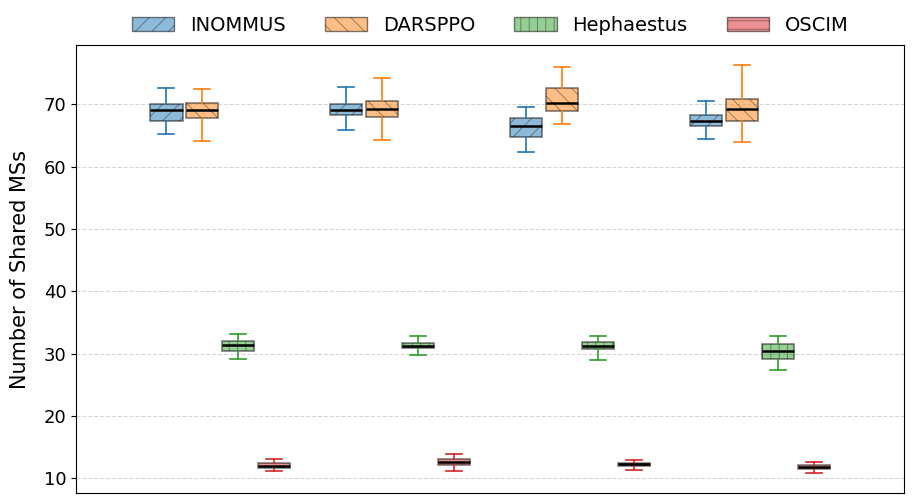

Gráfico exportado como PDF: boxplot_cpu_per_flow_with_Outliers.pdf


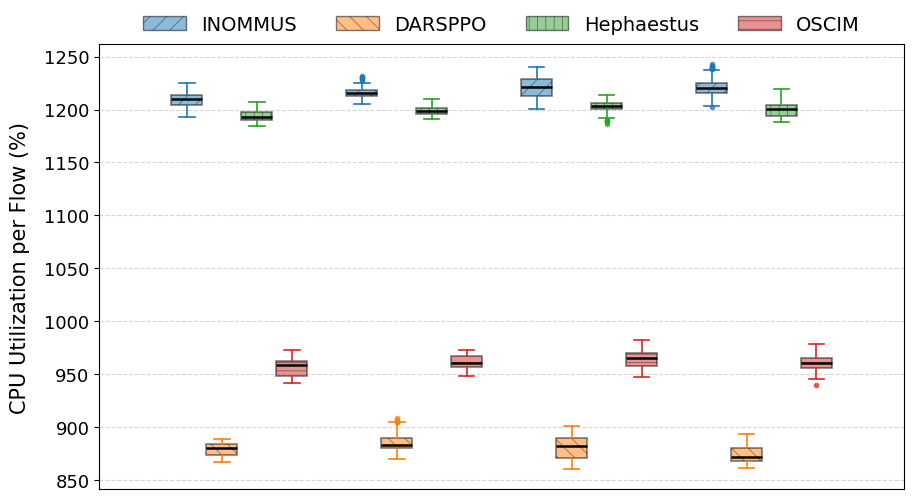

Gráfico exportado como PDF: boxplot_cpu_per_flow_Clean.pdf


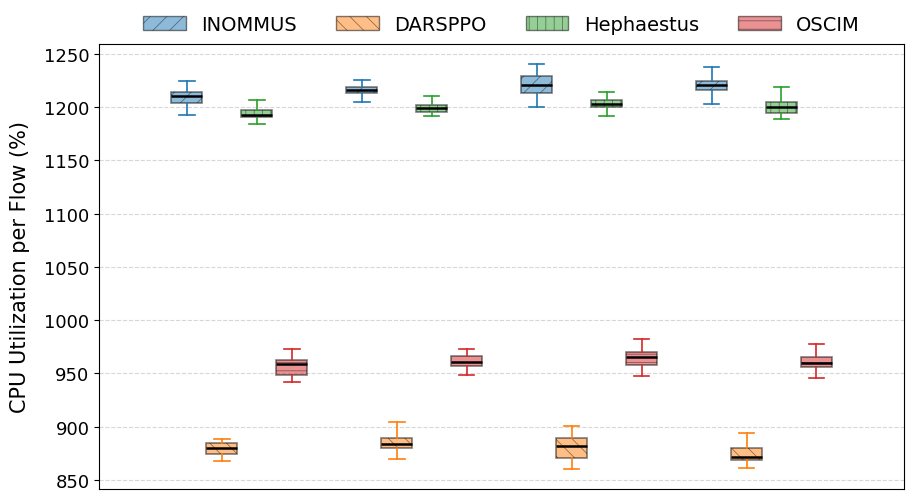

Gráfico exportado como PDF: boxplot_cache_per_flow_with_Outliers.pdf


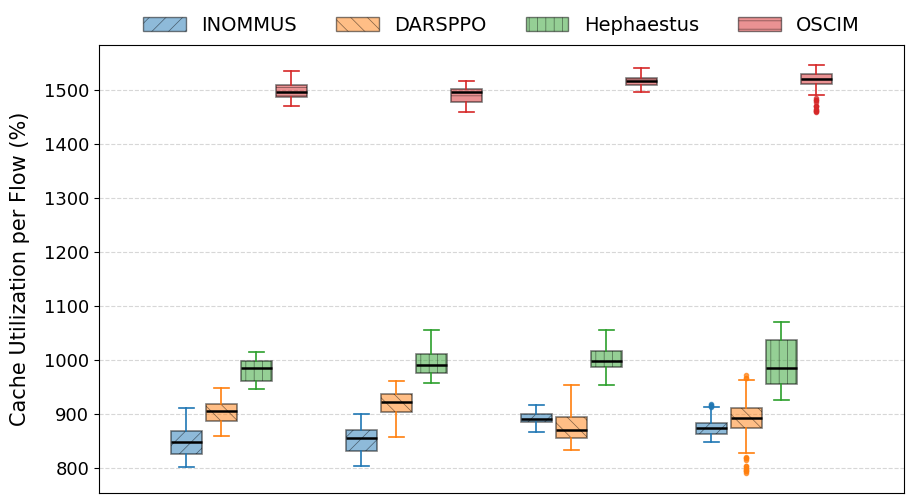

Gráfico exportado como PDF: boxplot_cache_per_flow_Clean.pdf


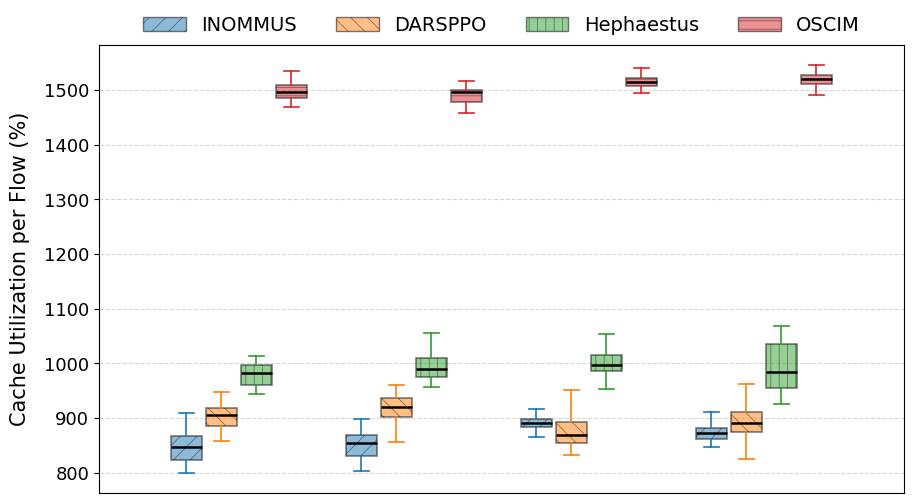

Gráfico exportado como PDF: boxplot_total_energy_consumption_with_Outliers.pdf


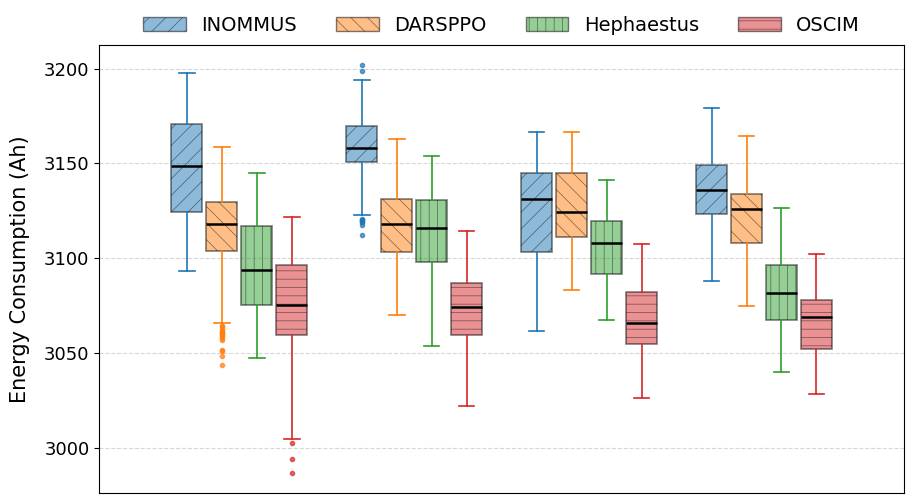

Gráfico exportado como PDF: boxplot_total_energy_consumption_Clean.pdf


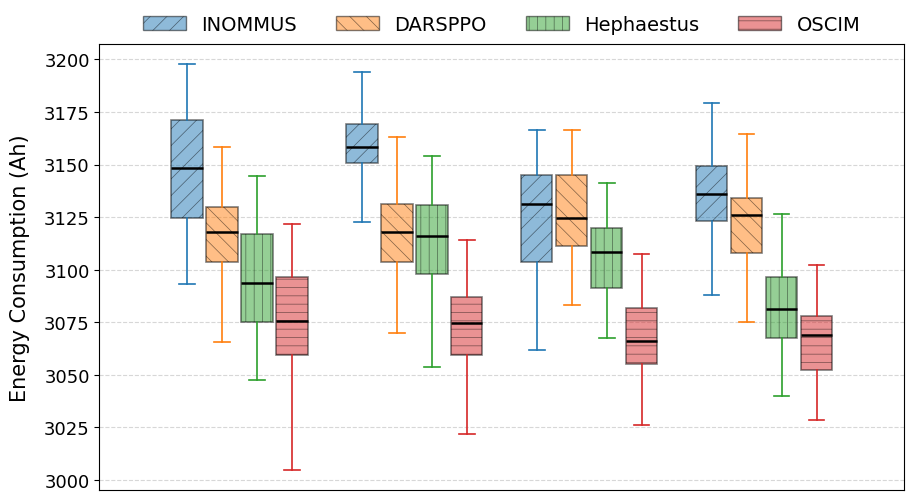

Gráfico exportado como PDF: boxplot_energy_consumption_per_flow_with_Outliers.pdf


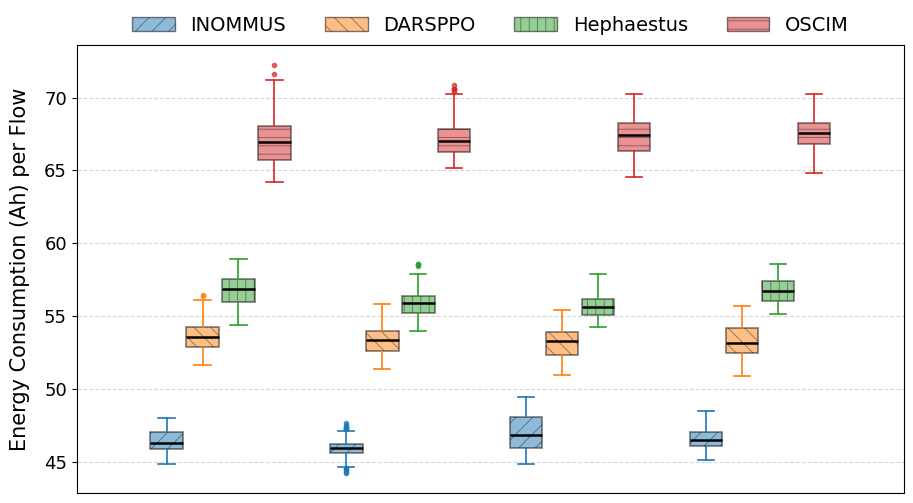

Gráfico exportado como PDF: boxplot_energy_consumption_per_flow_Clean.pdf


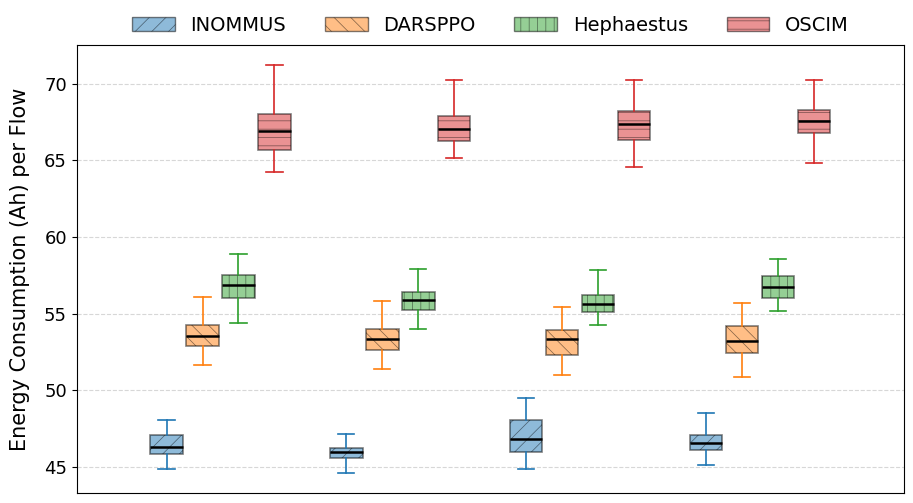

Gráfico exportado como PDF: boxplot_desvio_padrao_latencia_por_sessão_with_Outliers.pdf


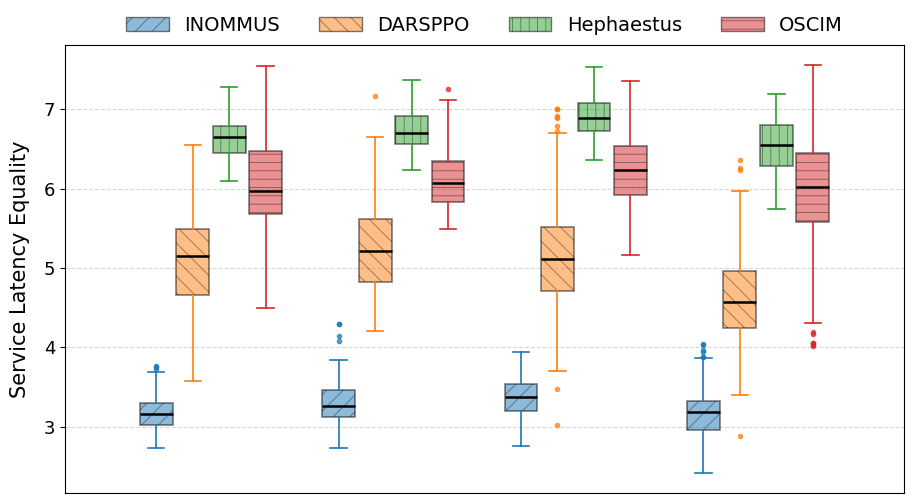

Gráfico exportado como PDF: boxplot_desvio_padrao_latencia_por_sessão_Clean.pdf


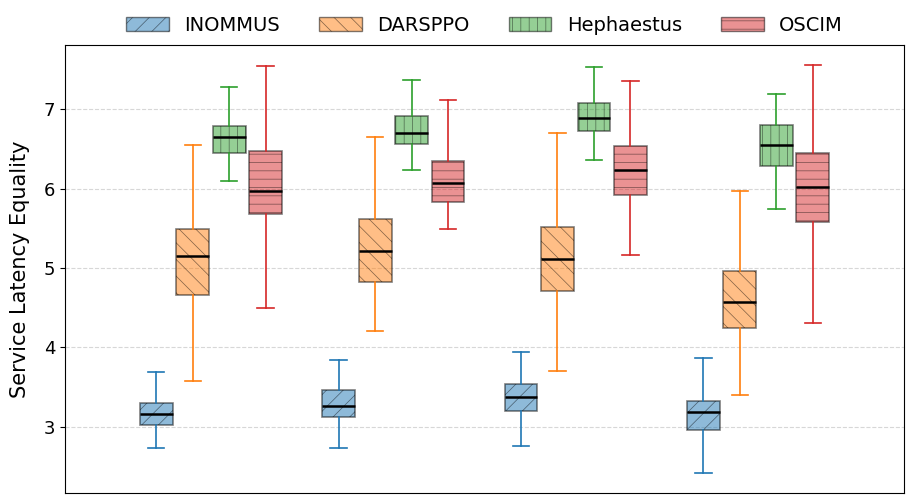

In [118]:
import re
import pandas as pd

# --- Métricas -> colunas (mantive os títulos que você já usa no eixo Y) ---
metricas = {
    "CPU Utilization (%)": "cpu_utilization",
    "Cache Utilization (%)": "cache_utilization",
    "Bandwidth Utilization (%)": "bandwidth_utilization",
    "Latency (ms)": "latency",
    "Acceptance Ratio (%)": "acceptance_rate",
    "Decision Time (ms)": "decision_time_ms",
    "Number of Shared MSs": "shared_vnfs",
    "CPU Utilization per Flow (%)": "cpu_per_flow",
    "Cache Utilization per Flow (%)": "cache_per_flow",
    "Energy Consumption (Ah)": "total_energy_consumption",
    "Energy Consumption (Ah) per Flow": "energy_consumption_per_flow",
    "Service Latency Equality": "desvio_padrao_latencia_por_sessão",
}

# --- Mapeamento de algoritmos para nomes de legenda ---
legendas = {
    'Kuririn PPO': 'INOMMUS',
    'DARSPPO': 'DARSPPO',
    'hephaestus': 'Hephaestus',
    'GA': 'OSCIM',
}

# --- Parâmetros consistentes com os gráficos anteriores ---
WINDOW_STEPS = 200        # tamanho da janela de tempo (bins)
EXPORT_PDF = True         # exportar PDF
FIG_W, FIG_H = 900, 500   # px (~ 9.4 x 5.2 in)

# Itera por métrica e plota duas versões (com/sem outliers)
for titulo_grafico, coluna_df in metricas.items():
    # Multiplica por 100 se for métrica em %
    multiplicador = 100 if "%" in titulo_grafico else 1

    # Monta dict {nome_legenda: série}
    dados_para_plotar = {}
    for alg_id, legenda_nome in legendas.items():
        if alg_id not in dados_processados:
            print(f"[AVISO] Algoritmo '{alg_id}' não encontrado em 'dados_processados'. Pulando.")
            continue
        df_alg = dados_processados[alg_id]
        if coluna_df not in df_alg.columns:
            print(f"[AVISO] Coluna '{coluna_df}' ausente para '{alg_id}'. Pulando.")
            continue

        s = pd.to_numeric(df_alg[coluna_df], errors="coerce") * multiplicador
        dados_para_plotar[legenda_nome] = s

    if not dados_para_plotar:
        print(f"[AVISO] Sem dados válidos para '{titulo_grafico}'. Pulando.")
        continue

    # Gera versões com e sem outliers
    for show_outliers in (True, False):
        suffix = "_with_Outliers" if show_outliers else "_Clean"
        safe_col = re.sub(r"[^\w\-]+", "_", coluna_df.strip())
        pdf_path = f"boxplot_{safe_col}{suffix}.pdf" if EXPORT_PDF else None

        # Create the boxplot with adjusted changes
        create_boxplot(
            data_series_dict=dados_para_plotar,
            yaxis_title=titulo_grafico,
            xaxis_title="",  # Removed the x-axis title
            steps=WINDOW_STEPS,
            fill_missing=True,
            bfill_leading=True,
            show=True,                     # Display the plot
            pdf_filename=pdf_path,         # Save PDF (if EXPORT_PDF=True)
            width=FIG_W,
            height=FIG_H,
            show_outliers=show_outliers,   # Aligned with Matplotlib helper
        )


In [108]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Dict, Optional, Tuple, List

def create_binned_boxplot(
    df_full: pd.DataFrame,
    x_col: str,
    y_col: str,
    alg_col: str,
    legend_map: Dict[str, str],
    bin_size: int = 10,
    x_multiplier: float = 100.0,
    yaxis_title: str = 'Y Axis',
    xaxis_title: str = 'X Axis',  # Add default xaxis_title
    show: bool = True,
    pdf_filename: Optional[str] = None,
    width: int = 950,
    height: int = 600,
    show_outliers: bool = True,
) -> Tuple[Optional[plt.Figure], pd.DataFrame]:
    """
    Creates grouped boxplots (Matplotlib) of y_col vs. binned x_col for each algorithm.
    Bins x_col values, groups by algorithm, and plots side-by-side boxes per bin.
    """

    # --- Prepare data ---
    df_plot = df_full.copy()
    df_plot = df_plot[df_plot[alg_col].isin(legend_map.keys())]

    if df_plot.empty:
        print("[ERRO] Nenhum dado encontrado para os algoritmos em 'legend_map'.")
        return None, pd.DataFrame()

    # Map algorithm names
    df_plot['Algorithm'] = df_plot[alg_col].map(legend_map)

    # Scale and bin x values
    df_plot[f"{x_col}_scaled"] = df_plot[x_col] * x_multiplier
    df_plot[f"{x_col}_bin"] = (np.ceil(df_plot[f"{x_col}_scaled"] / bin_size)) * bin_size
    df_plot[f"{x_col}_bin"] = df_plot[f"{x_col}_bin"].astype(int)

    # Sort bins
    x_bins = sorted(df_plot[f"{x_col}_bin"].unique())

    # --- Plot styling ---
    plt.rcParams['hatch.linewidth'] = 0.5
    plt.rcParams.update({
        'font.size': 13,
        'axes.labelsize': 14,
        'legend.fontsize': 12,
        'ytick.labelsize': 11,
        'axes.titlesize': 14,
    })

    dpi_guess = 96
    fig_w = max(6, width / dpi_guess)
    fig_h = max(4, height / dpi_guess)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    alg_order = list(df_plot['Algorithm'].unique())
    n_alg = len(alg_order)
    group_width = 0.8
    box_width = group_width / n_alg
    positions_base = np.arange(len(x_bins))

    # Colors & hatches
    def _color_for(i, name):
        try:
            return cores_algoritmos.get(name, plt.cm.tab10(i % 10))  # global palette
        except Exception:
            return plt.cm.tab10(i % 10)

    hatch_patterns = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']
    legend_handles: List[Patch] = []

    # --- Draw grouped boxplots ---
    for i, alg in enumerate(alg_order):
        color = _color_for(i, alg)
        hatch = hatch_patterns[i % len(hatch_patterns)]

        df_alg = df_plot[df_plot['Algorithm'] == alg]
        data_per_bin = [
            df_alg[df_alg[f"{x_col}_bin"] == xb][y_col].dropna().values
            for xb in x_bins
        ]

        offset = (i - n_alg / 2) * box_width + box_width / 2
        positions = positions_base + offset

        flier_style = dict(
            marker='o',
            markersize=3,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7
        )

        bp = ax.boxplot(
            data_per_bin,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=show_outliers,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5,
                          linewidth=1.2, edgecolor='black'),
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color=color, linewidth=1.2),
            capprops=dict(color=color, linewidth=1.2),
            flierprops=flier_style if show_outliers else dict(marker='o', markersize=0.1)
        )

        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.2)
            patch.set_alpha(0.5)
            patch.set_hatch(hatch)

        legend_handles.append(Patch(
            facecolor=color, edgecolor='black', hatch=hatch, alpha=0.5, label=alg
        ))

    # --- Axes formatting ---
    ax.set_ylabel(yaxis_title, labelpad=10)
    ax.set_xlabel(xaxis_title, labelpad=10)  # Restore x-axis title
    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(x) for x in x_bins], rotation=25)  # Show x-axis labels
    ax.tick_params(axis='x', which='both', bottom=True, top=False)  # Show ticks
    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    # Legend above the plot
    ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=min(4, n_alg),
        frameon=True,
        handlelength=2.2,
        borderpad=0.3,
        labelspacing=0.4
    )

    plt.tight_layout(pad=0.9)

    # --- Export ---
    if pdf_filename:
        try:
            fig.savefig(pdf_filename, dpi=300, bbox_inches='tight')
            print(f"Gráfico exportado como PDF: {pdf_filename}")
        except Exception as e:
            base, _ = os.path.splitext(pdf_filename)
            png_out = f"{base}.png"
            print(f"Falha ao exportar PDF ({e.__class__.__name__}). Salvando PNG.")
            fig.savefig(png_out, dpi=300, bbox_inches='tight')
            print(f"Gráfico exportado como PNG: {png_out}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, df_plot


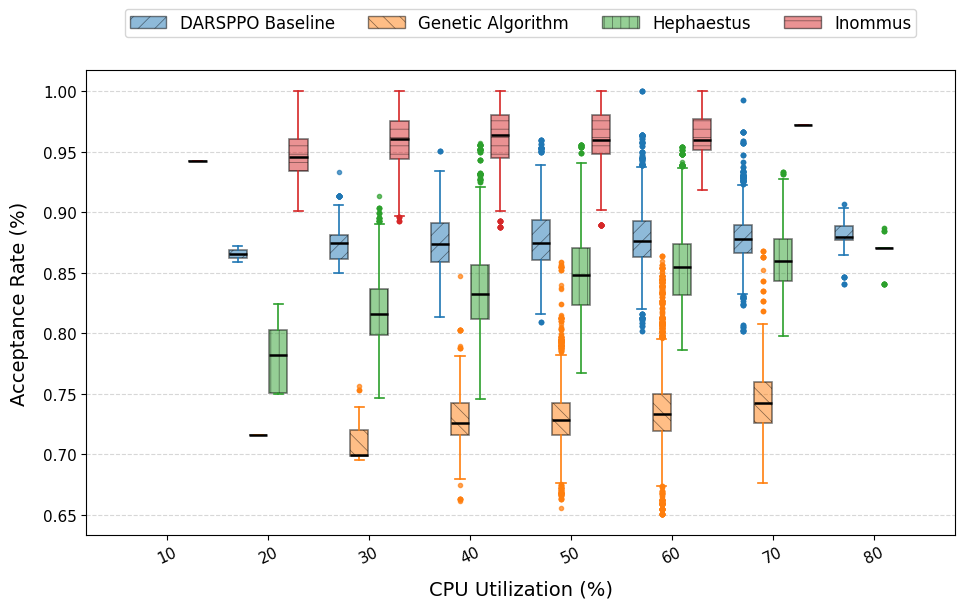

(<Figure size 989.583x625 with 1 Axes>,
      tempo  cpu_utilization  cache_utilization  bandwidth_utilization  \
 200    200          0.31920           0.449000               0.491900   
 201    201          0.31920           0.449000               0.491900   
 202    202          0.34115           0.482300               0.543817   
 203    203          0.34115           0.482300               0.543817   
 204    204          0.34115           0.482300               0.543817   
 ..     ...              ...                ...                    ...   
 995    995          0.45100           0.465667               0.276133   
 996    996          0.45100           0.465667               0.276133   
 997    997          0.45530           0.474000               0.267100   
 998    998          0.45530           0.474000               0.267100   
 999    999          0.45530           0.474000               0.267100   
 
       success    latency  decision_time_ms  running_sfcs  cpu_saved  

In [111]:
legendas_map = {
    'Kuririn PPO': 'Inommus',
    'DARSPPO': 'DARSPPO Baseline',
    'hephaestus': 'Hephaestus',
    'GA': 'Genetic Algorithm',
}

create_binned_boxplot(
    df_full=big_data,
    x_col='bandwidth_utilization',
    y_col='acceptance_rate',
    alg_col='algorithm',
    legend_map=legendas_map,
    bin_size=10,
    x_multiplier=100.0,
    yaxis_title='Acceptance Rate (%)',
    xaxis_title='CPU Utilization (%)'
)
